# Comprehensive Exploratory Data Analysis (EDA)
**Project:** Climbing Community and Routes Analysis  
**Description:** This notebook performs an in-depth study of the climbing datasets, exploring demographics, physical attributes, geographical distribution, and route popularity.

## 0. Environment Setup
In this section, we configure the notebook to access the project's source code and enable automatic reloading for the internal modules.

In [1]:
import sys
import os

# 1. Add the project root directory to sys.path to enable 'src' module discovery
sys.path.append(os.path.abspath(".."))

# 2. Enable autoreload extension to automatically update modules when changed
%load_ext autoreload
%autoreload 2

# 3. Import local project modules using standardized aliases
import src.io as io
import src.cleaning as cl
import src.features as ft
import src.viz as viz

## 1. Data Acquisition
In this stage, we retrieve the raw information using the centralized I/O system. As defined in our project configuration, we work with three primary datasets:

1. **Climbers**: Profile data, physical attributes, and performance history of users.
2. **Grades**: A reference table that maps numeric IDs to French climbing grades.
3. **Routes**: Detailed information about climbing routes, including sectors and ratings.

The function `io.load_all_raw_data()` iterates through the keys defined in our configuration and returns a dictionary containing all three DataFrames.

In [2]:
# Load all three datasets defined in config.py into a dictionary
dfs = io.load_all_raw_data()

# Display the keys to confirm that 'climbers', 'grades', and 'routes' are present
print(f"Successfully loaded datasets: {list(dfs.keys())}")

Successfully loaded datasets: ['climbers', 'grades', 'routes']


## 2. Initial Data Inspection (Data Profiling)
Before applying our cleaning pipeline, we must assess the current state of the raw data. We will inspect data types, detect missing values, and look for formatting inconsistencies that justify our cleaning logic.

### 2.1. Structural Overview and Data Types
We check the number of records, column names, and data types assigned by Pandas during the initial import. This helps identify columns that are not in the correct format (e.g., dates as strings or numeric IDs as floats).

In [3]:
# Loop through each dataset to show its structural information
for name, df in dfs.items():
    print(f"\n{20*'*'} Dataset: '{name}' {20*'*'}")
    df.info()


******************** Dataset: 'climbers' ********************
<class 'pandas.DataFrame'>
RangeIndex: 10927 entries, 0 to 10926
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       10927 non-null  int64  
 1   country       10927 non-null  str    
 2   sex           10927 non-null  int64  
 3   height        10927 non-null  int64  
 4   weight        10927 non-null  int64  
 5   age           10927 non-null  float64
 6   years_cl      10927 non-null  int64  
 7   date_first    10927 non-null  str    
 8   date_last     10927 non-null  str    
 9   grades_count  10927 non-null  int64  
 10  grades_first  10927 non-null  int64  
 11  grades_last   10927 non-null  int64  
 12  grades_max    10927 non-null  int64  
 13  grades_mean   10927 non-null  float64
 14  year_first    10927 non-null  int64  
 15  year_last     10927 non-null  int64  
dtypes: float64(2), int64(11), str(3)
memory usage: 1.3 MB

*****

### 2.2. Null Value Assessment
Identifying missing data is crucial. We calculate the sum of null values per column to determine which variables might need imputation or filtering during the feature engineering phase.

In [4]:
# Check for missing values in all DataFrames
for name, df in dfs.items():
    print(f"\n--- Null values in '{name}' ---")
    display(df.isna().sum())


--- Null values in 'climbers' ---


user_id         0
country         0
sex             0
height          0
weight          0
age             0
years_cl        0
date_first      0
date_last       0
grades_count    0
grades_first    0
grades_last     0
grades_max      0
grades_mean     0
year_first      0
year_last       0
dtype: int64


--- Null values in 'grades' ---


Unnamed: 0    0
grade_id      0
grade_fra     0
dtype: int64


--- Null values in 'routes' ---


Unnamed: 0            0
name_id               0
country               0
crag                  0
sector                0
name                  0
tall_recommend_sum    0
grade_mean            0
cluster               0
rating_tot            0
dtype: int64

### 2.3. Data Samples and Formatting Issues
By looking at the first few rows, we can spot obvious issues such as:
*   Inconsistent naming conventions (spaces, dots, capital letters).
*   Automatic index columns (like `Unnamed: 0`).
*   Inaccurate representations of categorical values (like `0/1` for sex).

In [5]:
# Visualize the head and basic statistics of each dataset
for name, df in dfs.items():
    print(f"\n--- Sample Data for '{name}' ---")
    display(df.head())
    
    # Statistical summary to detect outliers or range issues
    print(f"\n--- Descriptive Statistics for '{name}' ---")
    display(df.describe(include='all'))


--- Sample Data for 'climbers' ---


,user_id,country,sex,height,weight,age,years_cl,date_first,date_last,grades_count,grades_first,grades_last,grades_max,grades_mean,year_first,year_last
0,1,SWE,0,177,73,41.0,21,1999-02-06 23:00:00,2001-07-31 22:00:00,84,36,55,62,46.750000,1999,2001
1,3,SWE,0,180,78,44.0,22,1999-03-31 22:00:00,2000-07-19 22:00:00,12,53,51,59,52.833333,1999,2000
2,4,SWE,1,165,58,33.0,16,2004-06-30 22:00:00,2009-05-26 22:00:00,119,53,49,64,53.890756,2004,2009
3,10,SWE,0,167,63,52.0,25,2000-01-14 23:00:00,2017-06-01 22:00:00,298,53,49,63,49.406040,2000,2017
4,16,NOR,0,177,68,44.0,21,1998-02-27 23:00:00,2010-05-13 22:00:00,5,53,49,53,51.400000,1998,2010



--- Descriptive Statistics for 'climbers' ---


,user_id,country,sex,height,weight,age,years_cl,date_first,date_last,grades_count,grades_first,grades_last,grades_max,grades_mean,year_first,year_last
count,10927.00000,10927,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927,10927,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000,10927.000000
unique,NaN,26,NaN,NaN,NaN,NaN,NaN,4443,3882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,ESP,NaN,NaN,NaN,NaN,NaN,2005-12-31 23:00:00,2017-09-09 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1306,NaN,NaN,NaN,NaN,NaN,32,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,29411.09774,NaN,0.125103,176.152009,67.608676,33.333852,12.672188,NaN,NaN,79.794546,45.648851,46.983802,53.764437,45.505055,2008.621946,2012.311613
std,18022.12695,NaN,0.330851,8.508669,9.677316,7.590989,6.108451,NaN,NaN,141.411297,9.478173,9.418087,9.679533,7.891356,28.833298,4.161484
min,1.00000,NaN,0.000000,137.000000,40.000000,12.000000,1.000000,NaN,NaN,1.000000,28.000000,28.000000,29.000000,28.500000,0.000000,1991.000000
25%,14651.00000,NaN,0.000000,171.000000,63.000000,28.000000,8.000000,NaN,NaN,8.000000,38.000000,40.000000,46.000000,39.400000,2006.000000,2009.000000
50%,27323.00000,NaN,0.000000,177.000000,68.000000,33.000000,12.000000,NaN,NaN,28.000000,46.000000,48.000000,55.000000,45.151899,2009.000000,2013.000000
75%,43240.50000,NaN,0.000000,182.000000,73.000000,38.000000,17.000000,NaN,NaN,90.000000,53.000000,53.000000,62.000000,51.210084,2012.000000,2016.000000



--- Sample Data for 'grades' ---


...

,Unnamed: 0,grade_id,grade_fra
count,85.000000,85.000000,85
unique,NaN,NaN,83
top,NaN,NaN,-
freq,NaN,NaN,3
mean,42.000000,42.000000,NaN
std,24.681302,24.681302,NaN
min,0.000000,0.000000,NaN
25%,21.000000,21.000000,NaN
50%,42.000000,42.000000,NaN
75%,63.000000,63.000000,NaN



--- Sample Data for 'routes' ---


,Unnamed: 0,name_id,country,crag,sector,name,tall_recommend_sum,grade_mean,cluster,rating_tot
0,0,0,and,montserrat,prohibitivo,diagonal de la x,-1,49.250000,3,-0.045211
1,1,1,and,montserrat,prohibitivo,mehir,-1,49.000000,2,0.116464
2,2,2,and,montserrat,prohibitivo,pas de la discordia,0,49.000000,2,0.178722
3,3,3,and,tartareu,bombo suis,tenedor libre,0,44.333333,3,0.158449
4,4,4,arg,bandurrias,rincon,tendinitis,1,48.500000,0,0.075797



--- Descriptive Statistics for 'routes' ---


,Unnamed: 0,name_id,country,crag,sector,name,tall_recommend_sum,grade_mean,cluster,rating_tot
count,55858.000000,55858.000000,55858,55858,55858,55858,55858.000000,55858.000000,55858.000000,5.585800e+04
unique,NaN,NaN,59,2245,2463,48468,NaN,NaN,NaN,NaN
top,NaN,NaN,esp,frankenjura,vermell,sin nombre,NaN,NaN,NaN,NaN
freq,NaN,NaN,15293,1596,316,31,NaN,NaN,NaN,NaN
mean,27928.500000,27928.500000,NaN,NaN,NaN,NaN,0.023041,46.799255,2.210588,1.704550e-17
std,16124.960005,16124.960005,NaN,NaN,NaN,NaN,0.965519,9.168034,1.708326,1.404031e-01
min,0.000000,0.000000,NaN,NaN,NaN,NaN,-16.000000,29.000000,0.000000,-1.822021e-01
25%,13964.250000,13964.250000,NaN,NaN,NaN,NaN,0.000000,39.937500,2.000000,-7.347453e-02
50%,27928.500000,27928.500000,NaN,NaN,NaN,NaN,0.000000,46.000000,2.000000,-4.284822e-02
75%,41892.750000,41892.750000,NaN,NaN,NaN,NaN,0.000000,53.000000,2.000000,4.529507e-02


## 3. Data Cleaning and Standardization
To ensure the reliability of our analysis, we apply a strict cleaning pipeline. This process involves:

*   **Column Standardization**: Converting all names to lowercase and replacing spaces/dots with underscores.
*   **Dimensionality Reduction**: Dropping unnecessary index columns like `Unnamed: 0`.
*   **Type Casting**: Converting numeric identifiers to `Int64` (nullable integers) and categorical strings to `category` for memory efficiency.
*   **Semantic Mapping**: Replacing numeric codes (0/1) in the `sex` column with human-readable labels (male/female).
*   **Temporal Formatting**: Parsing date strings into proper `datetime` objects.

In [6]:
# Apply the master cleaning function to the dictionary of raw DataFrames
# This will return a new dictionary with clean, standardized data
cleaned_dfs = cl.clean_all_data(dfs)

print("Cleaning pipeline executed successfully.")

Cleaning pipeline executed successfully.


### 3.1. Post-Cleaning Verification
We perform a quick check to verify that column names are now standardized and data types are correctly assigned.

In [7]:
# Show the results of the cleaning for one representative dataset
print("--- Standardized Columns and Types (Climbers) ---")
cleaned_dfs['climbers'].info()

# Preview the head to ensure human-readable labels are applied
display(cleaned_dfs['climbers'].head())

--- Standardized Columns and Types (Climbers) ---
<class 'pandas.DataFrame'>
RangeIndex: 10927 entries, 0 to 10926
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       10927 non-null  Int64         
 1   country       10927 non-null  category      
 2   sex           10927 non-null  category      
 3   height        10927 non-null  Int64         
 4   weight        10927 non-null  Int64         
 5   age           10927 non-null  Int64         
 6   years_cl      10927 non-null  Int64         
 7   date_first    10927 non-null  datetime64[us]
 8   date_last     10927 non-null  datetime64[us]
 9   grades_count  10927 non-null  Int64         
 10  grades_first  10927 non-null  Int64         
 11  grades_last   10927 non-null  Int64         
 12  grades_max    10927 non-null  Int64         
 13  grades_mean   10927 non-null  float64       
 14  year_first    10927 non-null  Int64         
 1

,user_id,country,sex,height,weight,age,years_cl,date_first,date_last,grades_count,grades_first,grades_last,grades_max,grades_mean,year_first,year_last
0,1,SWE,male,177,73,41,21,1999-02-06 23:00:00,2001-07-31 22:00:00,84,36,55,62,46.750000,1999,2001
1,3,SWE,male,180,78,44,22,1999-03-31 22:00:00,2000-07-19 22:00:00,12,53,51,59,52.833333,1999,2000
2,4,SWE,female,165,58,33,16,2004-06-30 22:00:00,2009-05-26 22:00:00,119,53,49,64,53.890756,2004,2009
3,10,SWE,male,167,63,52,25,2000-01-14 23:00:00,2017-06-01 22:00:00,298,53,49,63,49.406040,2000,2017
4,16,NOR,male,177,68,44,21,1998-02-27 23:00:00,2010-05-13 22:00:00,5,53,49,53,51.400000,1998,2010


## 4. Feature Engineering and Data Integrity
With the data standardized, we now derive new metrics and categories. This phase is crucial not only for adding analytical value but also for fixing remaining **Data Integrity** issues found in the raw files:

**Climbers: Temporal and Physical Metrics**
*   **Temporal Recalculation**: The raw columns `year_first` and `year_last` contained impossible values (e.g., years 0 or 1095). We extract these years directly from the cleaned `datetime` objects to ensure accuracy.
*   **Platform Tenure**: We calculate `years_recorded` (Delta between first and last recorded climb). Records with negative results (chronological errors) are strictly removed.
*   **Physical Profile**: `bmi` is calculated and placed next to weight for better physical context.

**Routes: Integration and Popularity**
*   **Merge Key**: We create an integer `grade_id` by rounding the average grade, enabling a clean join with the grades reference table.
*   **Categorical Popularity**: Instead of boolean flags, routes are classified into four levels ('Quiet' to 'Classic') based on rating quantiles.
*   **Sector Density**: `routes_in_sector` is created to study the scale of climbing areas.

**Grades: Expertise Classification**
*   **Broad Level Extraction**: Simplifying technical grades (e.g., extracting "6" from "6a+").
*   **Expertise Bins**: Categorizing technical IDs into human-readable levels from 'Beginner' to 'Elite', specifically handling 'Unrated' cases.

In [8]:
# Execute the comprehensive feature engineering pipeline
# This transforms our cleaned dictionary into a featured dictionary
featured_dfs = ft.build_all_features(cleaned_dfs)

print("Feature engineering and data integrity filters applied successfully.")

Feature engineering and data integrity filters applied successfully.


### 4.1. Post-Feature Engineering Verification
We verify that the integrity filters (removal of chronological errors) and the new calculated metrics (BMI, Categories) are consistent and ready for visual analysis.

In [9]:
# 1. Verify Climber integrity and new metrics
climbers = featured_dfs['climbers']
print(f"--- Climbers Integrity Check ---")
print(f"Valid year range: {climbers['year_first'].min()} to {climbers['year_last'].max()}")
print(f"Negative activity spans found: {(climbers['years_recorded'] < 0).sum()}")
display(climbers[['user_id', 'bmi', 'years_recorded', 'time_first']].head())

# 2. Verify Route and Grade categorizations
routes = featured_dfs['routes']
grades = featured_dfs['grades']

print(f"\n--- Categorization Overview ---")
print("Route Popularity counts:")
display(routes['popularity_level'].value_counts())

print("\nGrade Category mapping sample:")
display(grades[['grade_id', 'grade_fra', 'grade_category']].head(10))

--- Climbers Integrity Check ---
Valid year range: 1970 to 2017
Negative activity spans found: 0


,user_id,bmi,years_recorded,time_first
0,1,23.3,2,23:00:00
1,3,24.07,1,22:00:00
2,4,21.3,5,22:00:00
3,10,22.59,17,23:00:00
4,16,21.71,12,23:00:00



--- Categorization Overview ---
Route Popularity counts:


popularity_level
Quiet           17781
Classic         13965
Highly Rated    13963
Regular         10149
Name: count, dtype: int64


Grade Category mapping sample:


,grade_id,grade_fra,grade_category
0,0,-,Unrated
1,1,-,Unrated
2,2,-,Unrated
3,3,1,Beginner
4,4,1a,Beginner
5,5,1b,Beginner
6,6,1c,Beginner
7,7,1+,Beginner
8,8,2,Beginner
9,9,2a,Beginner


## 5. Visual Analysis and Insights
With the data cleaned and enriched, we proceed to the exploratory visualization phase. Our analysis is structured into specific study areas to gain a comprehensive understanding of the climbing community and route distribution:

*   **Sex and Performance Study**: We examine gender distribution and analyze how climbing performance (maximum and average grades) evolves over years of experience for different sexes.
*   **BMI and Physical Attributes Study**: We explore the physical profile of the population, specifically focusing on the distribution of Body Mass Index (BMI) and its potential correlation with climbing success.
*   **Geographical Study**: A high-level overview of which countries are the most active in terms of both number of registered climbers and available climbing routes.
*   **Route Popularity and Rankings**: We study the relationship between route difficulty and popularity to identify "Classic" routes, and generate a ranked table of the top performing climbers in the dataset.
*   **Correlation Study**: A mathematical summary using heatmaps to identify which factors (Age, BMI, Experience) have the strongest influence on climbing performance.

### 5.1. Sex and Performance Study
In this section, we analyze the demographic balance of the community and investigate if there are significant performance gaps between sexes. 
* The **Pie Chart** reveals the gender distribution.
* The **Regression Plot** shows the "velocity" of improvement over the years.
* The **Boxplot** compares the statistical spread and median skill levels.

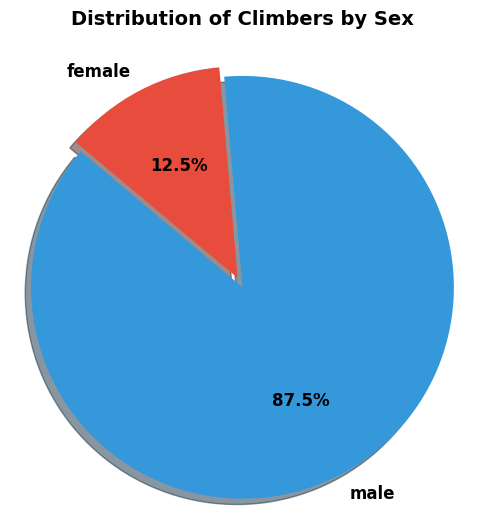

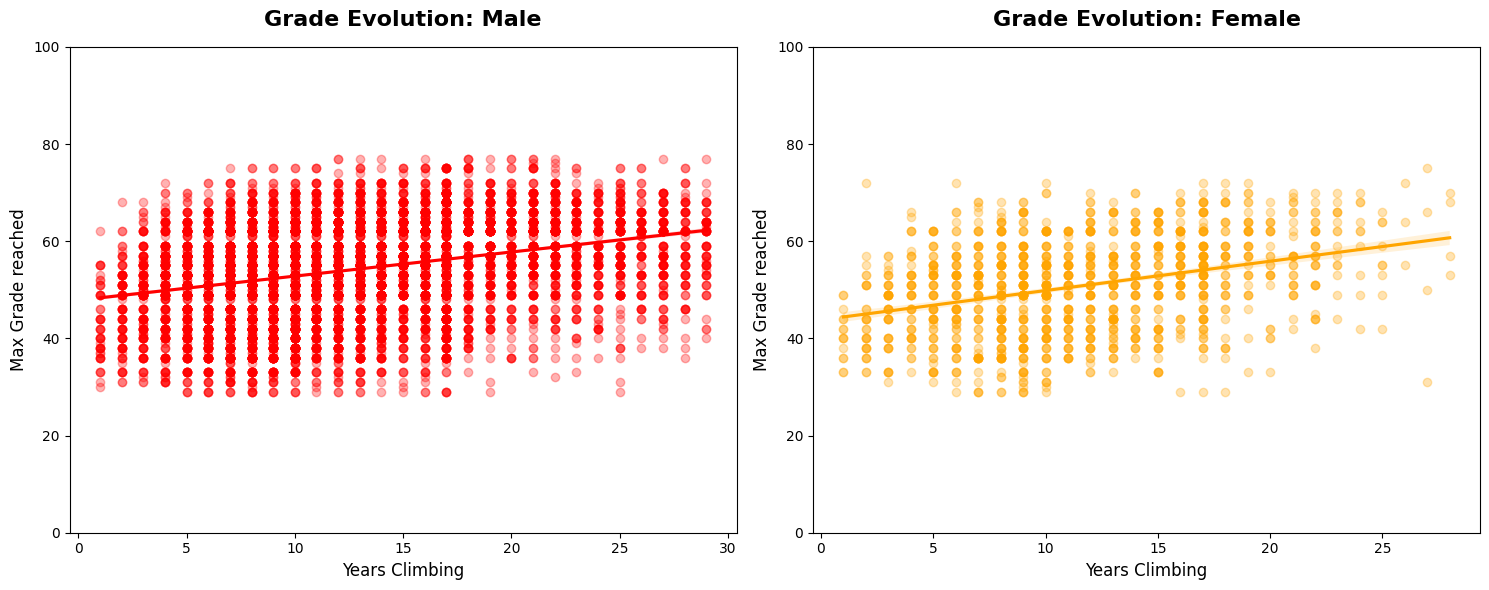

c:\Users\Pablo\Desktop\Drive\Evolve\Proyecto\src\viz.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='grades_mean', palette='pastel')


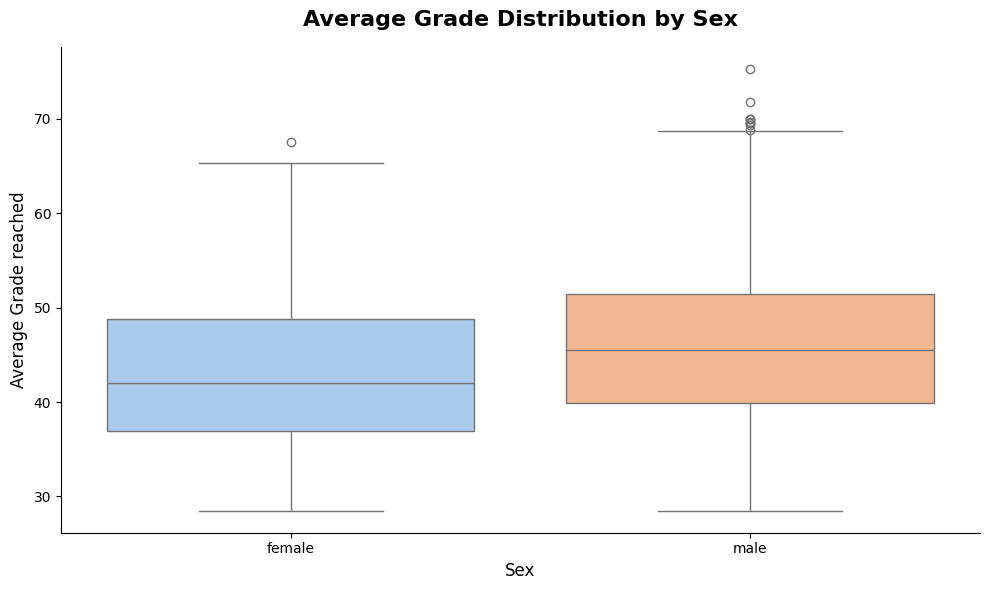

In [10]:
# General sex distribution
viz.plot_sex_distribution(featured_dfs['climbers'])

# Grade evolution over years of experience
viz.plot_grade_evolution_by_sex(featured_dfs['climbers'])

# Statistical distribution of average grades
viz.plot_grade_distribution_by_sex(featured_dfs['climbers'])

> **Key Insights - Sex & Performance:**
> * **Gender Imbalance**: There is a massive demographic gap in the dataset, with **87.5% of climbers being male** and **12.5% female**. This high disproportion suggests that the overall community trends and population-wide averages are predominantly shaped by the male majority.
> * **High Dispersion in Progression**: Although the regression lines show a gradual upward slope, the data points are **highly dispersed** (blurred). This indicates that years of experience are only a weak predictor of success; individual performance varies wildly at every stage of seniority, suggesting that factors like specific training, genetics, or technical talent are likely more influential than time alone.
> * **Skill-Based Parity**: Despite the gender imbalance, the grade distribution (Boxplot) shows that the median performance levels are remarkably close. The significant overlap between male and female distributions supports the idea that in climbing, technical mastery and relative physical attributes can level the playing field, making the sport less gender-dependent than other athletic disciplines.

### 5.2. BMI and Physical Attributes Study
In climbing, the **power-to-weight ratio** is a fundamental biomechanical principle. In this section, we analyze the physical profile of the community through the Body Mass Index (BMI) and investigate its direct influence on climbing performance.

*   The **Histogram** illustrates the common physical build within the population.
*   The **Density Heatmap (Hexbin)** reveals where the majority of the community "lives" in terms of physical build and skill, while the regression line quantifies the impact of weight relative to height on average grades.

Plot saved successfully at: C:\Users\Pablo\Desktop\Drive\Evolve\Proyecto\data\figures\physical_attributes\bmi_distribution_histogram.png


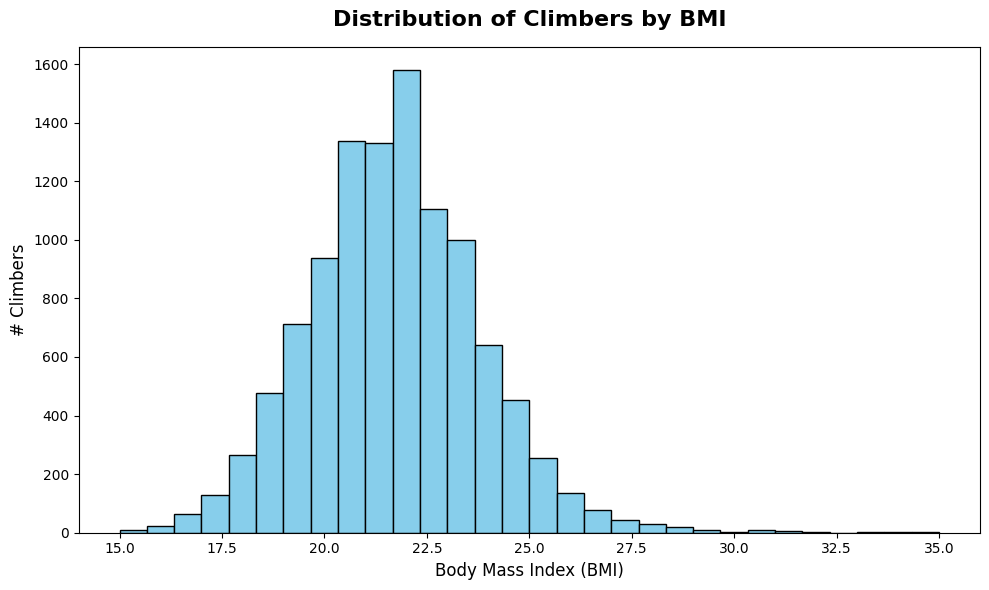

Plot saved successfully at: C:\Users\Pablo\Desktop\Drive\Evolve\Proyecto\data\figures\physical_attributes\bmi_vs_grade_density.png


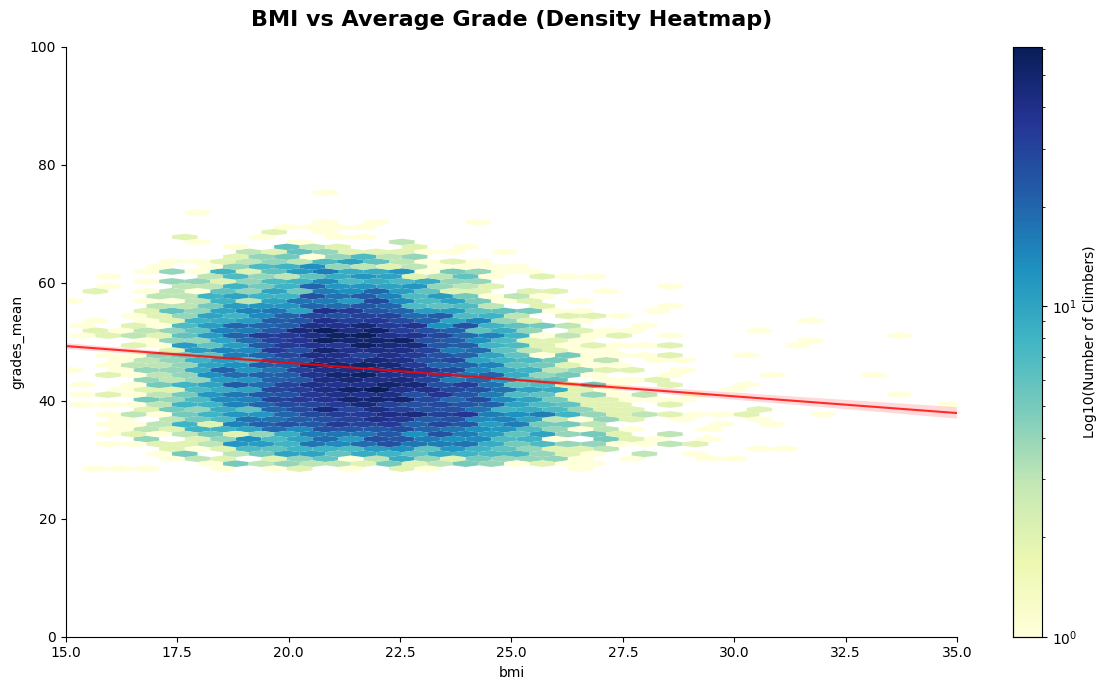

In [ ]:
# Visualize the BMI frequency across the population
viz.plot_bmi_distribution(featured_dfs['climbers'])

# Analyze the density and correlation between BMI and Average Performance
viz.plot_grade_mean_vs_bmi_density(featured_dfs['climbers'])

> **Key Insights - BMI & Physical Attributes:**
> * **Lean Community Bias**: The BMI distribution shows a clear concentration between **21 and 23**. The population is predominantly lean, with a sharp decrease in participation as BMI moves beyond 25, suggesting a natural selection towards lower weight-to-height ratios in the sport.
> * **Weak Correlation**: Although the trend line shows a slight downward slope, the correlation is **not decisive**. There is high variability across all BMI levels; a lower BMI does not automatically translate to higher grades, indicating that technical skill and specific training likely outweigh raw body metrics.
> * **Elite Physical Constraint**: While BMI is a poor predictor for the general population, the highest performance tiers (average grades > 60) are almost exclusively occupied by climbers with a BMI below 25. This suggests that while being lean doesn't make you an expert, it may be a "necessary but not sufficient" condition for reaching elite levels.
> * **The Average Climber "Hub"**: The highest density of data is found around **BMI 22 with an Average Grade of 45-50**. This defines the standard "profile" of the active community on this platform.

### 5.3. Geographical Study
Geography plays a major role in the climbing community, often defined by the proximity to natural rock and the historical development of climbing areas. In this section, we analyze the distribution of climbers and routes across the globe to identify the most active regions.

*   **Climbers by Country**: Highlights the demographic origins of the platform's user base.
*   **Routes by Country**: Measures the "climbing infrastructure" available in each nation, identifying the world's primary climbing destinations.

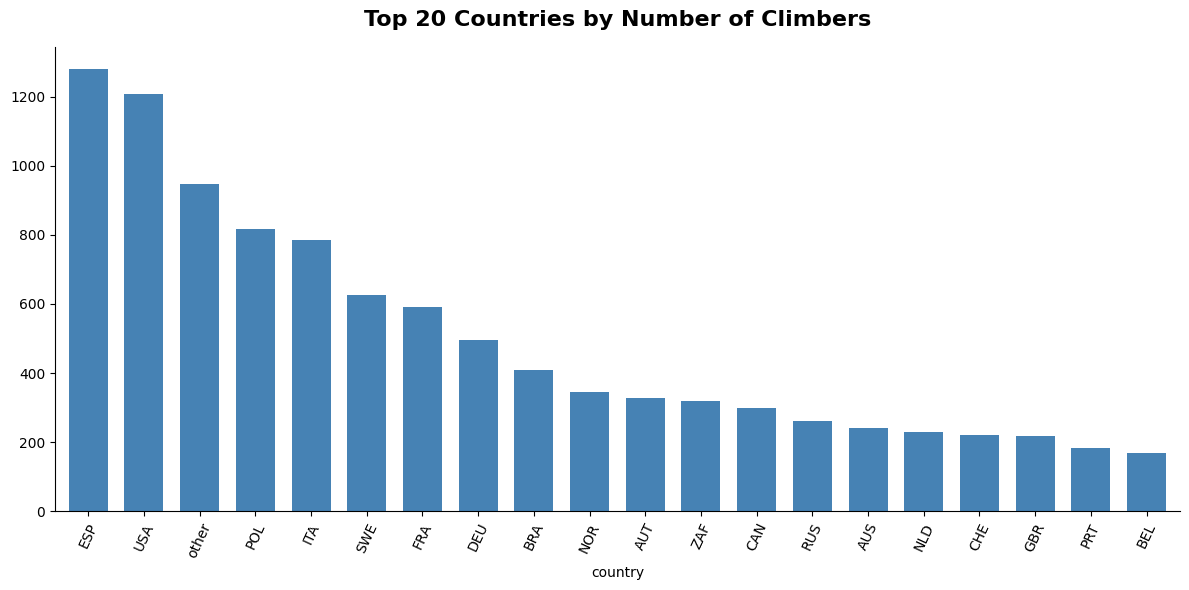

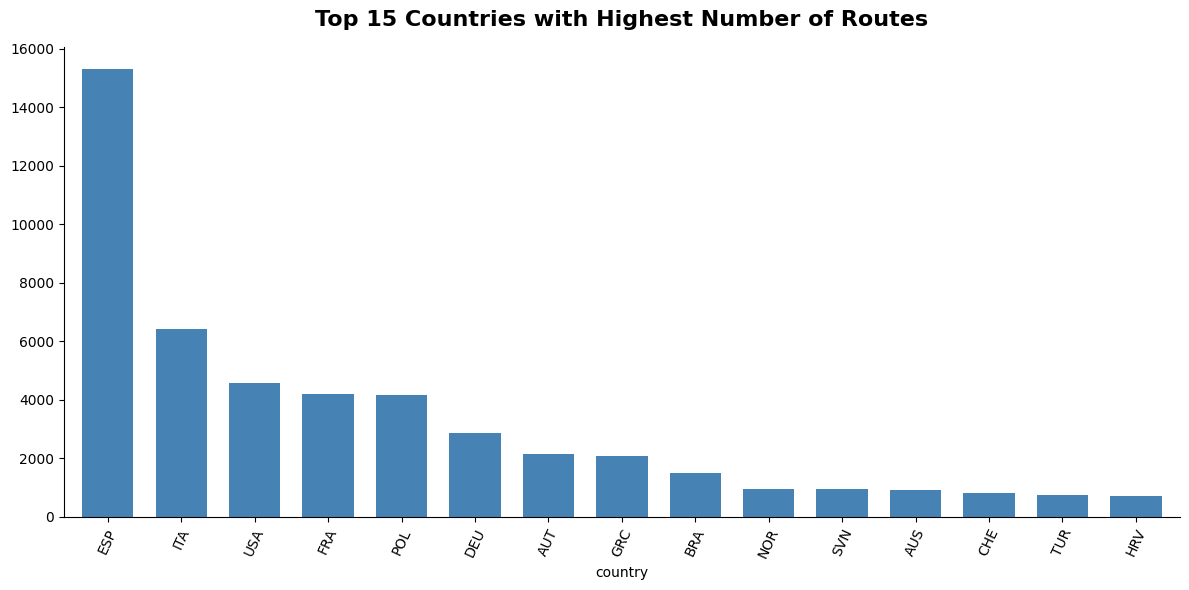

In [12]:
# Analyze the top countries by number of registered climbers
viz.plot_climbers_by_country(featured_dfs['climbers'], top_n=20)

# Analyze the top countries by volume of climbing routes
viz.plot_routes_by_country(featured_dfs['routes'], top_n=15)

> **Key Insights - Geographical Study:**
> * **Spanish Hegemony**: Spain (**ESP**) is the undisputed leader in both categories. It has the highest number of climbers and a massive volume of routes (over 15,000), nearly tripling the next closest country. This suggests the platform has a very strong Spanish core or that Spain is the primary global hub for recorded sport climbing.
> * **European Dominance**: The dataset is heavily concentrated in Europe. Countries like **Italy, France, Poland, and Germany** consistently appear at the top of both lists, indicating that the platform's data predominantly reflects the European climbing scene.
> * **USA Activity**: The **USA** ranks second in terms of climbers but falls to third in terms of routes. This might indicate a very active user base that frequently records climbs, even if the total volume of routes logged for that region is lower than in European countries.
> * **The "Other" Tail**: In the climber distribution, the "other" category is significant, showing that while a few countries dominate, there is a very large "long tail" of climbers from many different nations contributing to the dataset.

### 5.4. Route Popularity and Rankings
In this section, we study the relationship between route difficulty and its perceived quality ("Classic" status). To gain a full perspective, we use dual scales for popularity and then recognize the community's top performers with a detailed ranking.

*   **Popularity Comparison**: Uses **Linear** (volume) and **Logarithmic** (proportions) scales to identify quality trends across all skill levels.
*   **Top 20 Climbers Ranking**: A detailed table identifying the most elite individuals in the dataset, sorted by max grade and age.

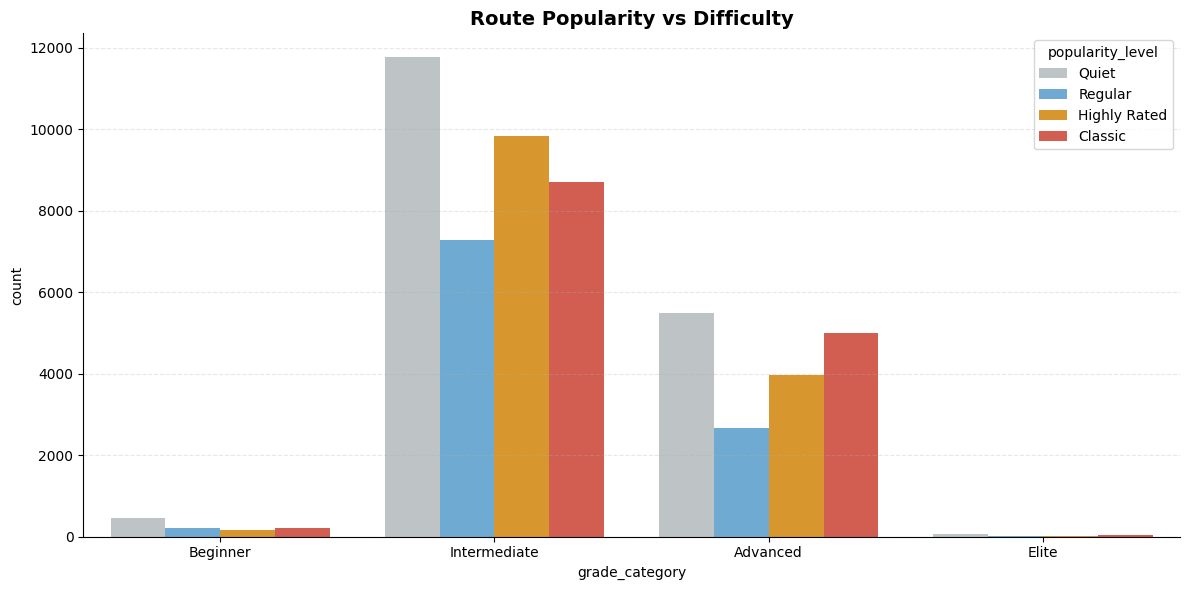

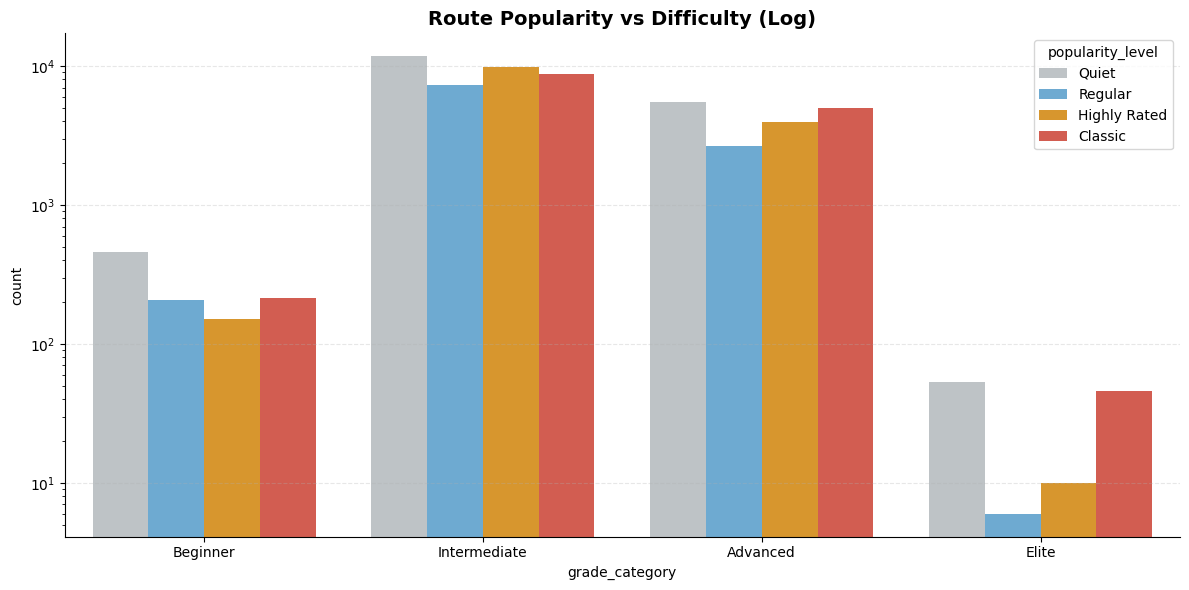

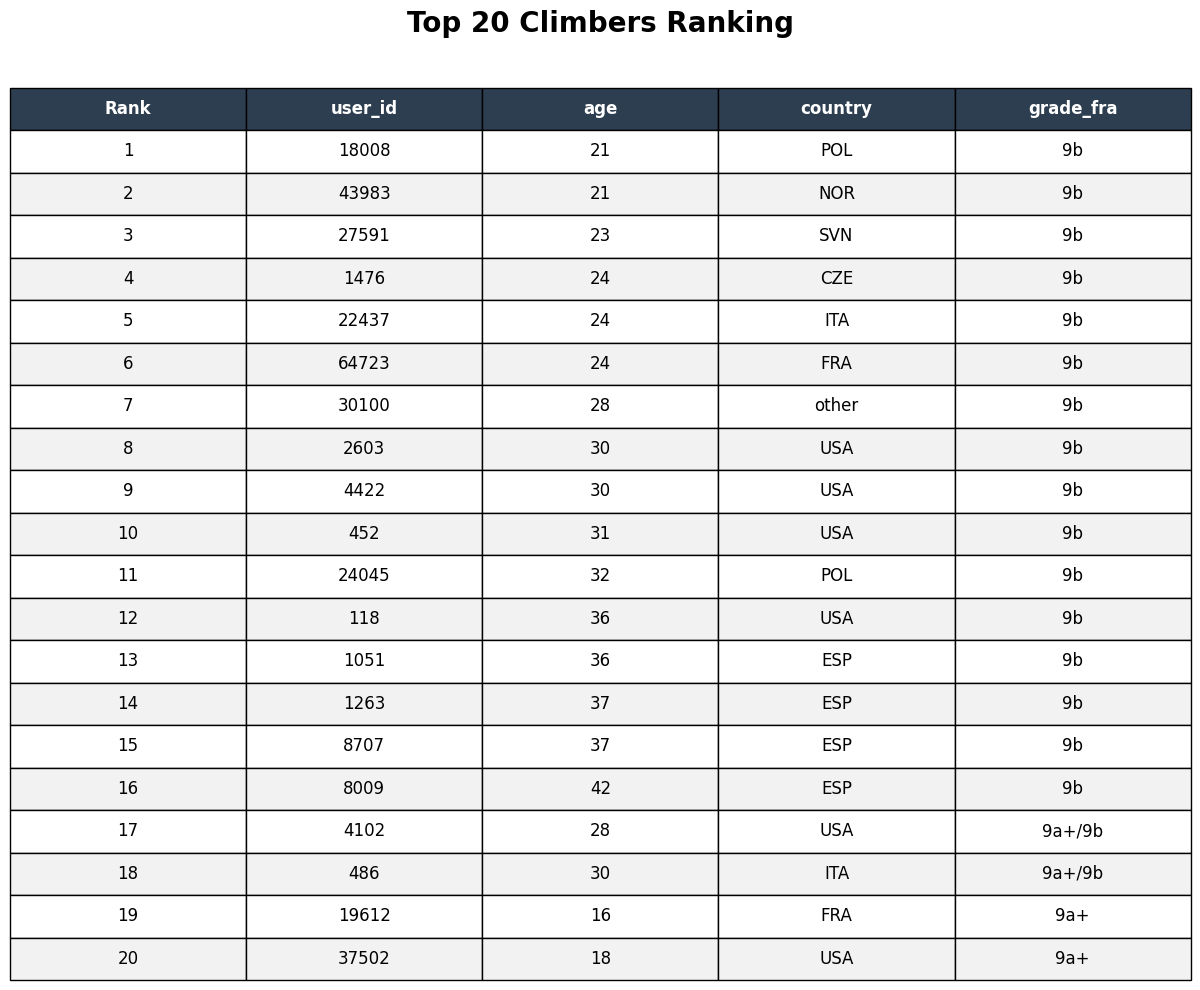

In [13]:
# 1. Generate popularity plots (Linear & Log)
viz.plot_popularity_comparison(featured_dfs['routes'], featured_dfs['grades'])

# 2. Generate the visual Ranking Table
viz.plot_top_climbers_table(featured_dfs['climbers'], featured_dfs['grades'], top_n=20)

> **Key Insights - Routes & Elite Rankings:**
> * **Climbing for the Masses**: The linear chart confirms that the vast majority of infrastructure and activity is focused on the **Intermediate** level. However, the **Logarithmic Scale** reveals that the highest proportion of "Classic" (top-tier quality) routes is concentrated in the **Advanced** and **Elite** tiers.
> * **The "Classic" Threshold**: Highly rated routes become proportionally more frequent as difficulty increases, suggesting that high-level climbers are either more active in rating or that elite routes are developed with a higher focus on quality.
> * **Technical Peak and Maturity**: The ranking table is dominated by world-class **9b** grades. A standout observation is the **age diversity of the elite**: from 16-year-old talents to 42-year-old veterans. This proves that climbing performance relies on a balance of youthful explosiveness and long-term technical experience.
> * **International Elite Hubs**: The top climbers hail from diverse nations (POL, NOR, ESP, USA, ITA), mirroring the geographical dominance of Europe and the USA previously identified in the study.

### 5.5. Correlation Study
To conclude our exploratory analysis, we use mathematical correlation matrices to identify the primary drivers of climbing performance. We compare two distinct scenarios:

1.  **Declared Experience**: Based on the `years_cl` column (how long the user claims to have been climbing).
2.  **Platform Experience**: Based on our engineered `years_recorded` feature (the actual time span of recorded activity on the platform).

These heatmaps allow us to quantify the influence of physical attributes (BMI), age, and experience on the technical grades achieved.

Plot saved successfully at: C:\Users\Pablo\Desktop\Drive\Evolve\Proyecto\data\figures\correlations\correlation_bmi_vs_performance_declared.png


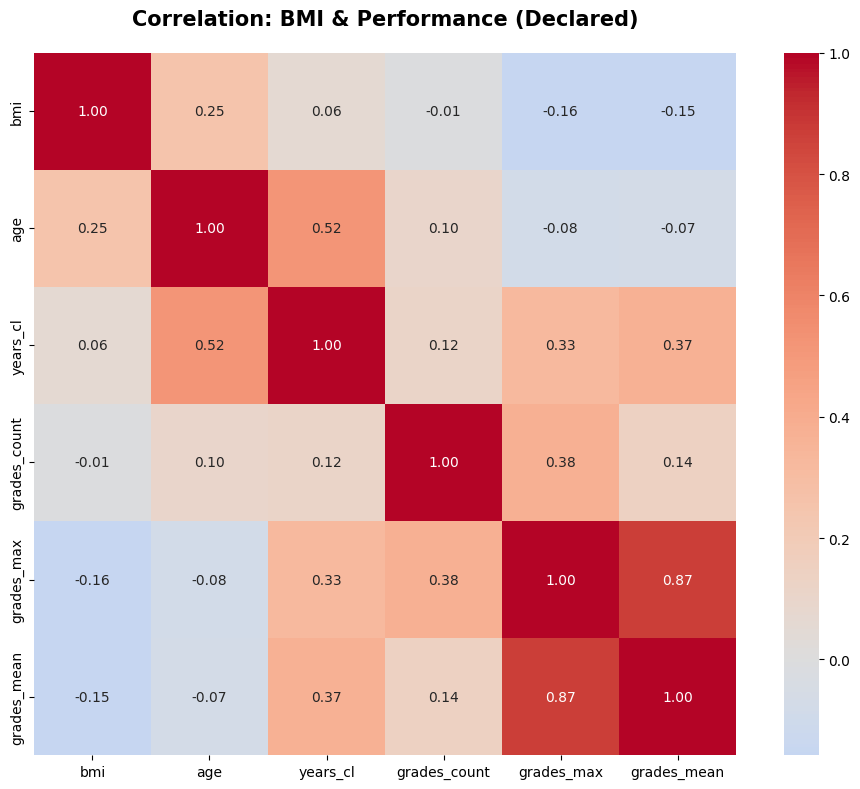

Plot saved successfully at: C:\Users\Pablo\Desktop\Drive\Evolve\Proyecto\data\figures\correlations\correlation_bmi_vs_performance_recorded.png


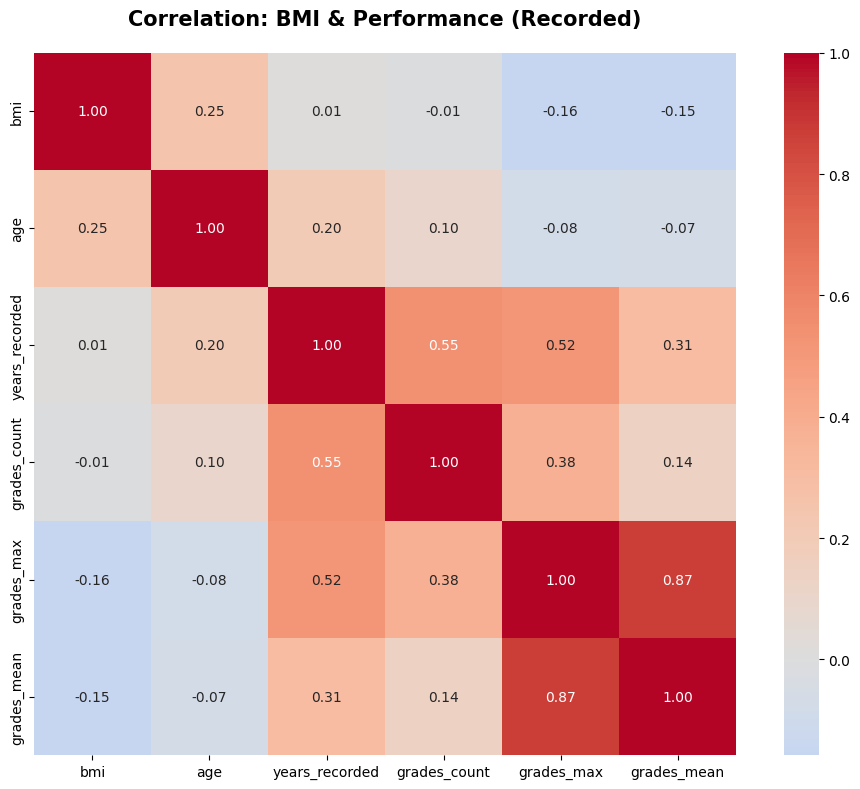

In [ ]:
# Correlation using declared experience (years_cl)
viz.plot_correlation_bmi_vs_performance(featured_dfs['climbers'])

# Correlation using platform-recorded experience (years_recorded)
viz.plot_correlation_bmi_vs_recorded(featured_dfs['climbers'])

> **Key Insights - Correlation Study:**
> * **Recorded vs. Declared Experience**: The most significant finding is that **Platform Experience (`years_recorded`) is a much stronger predictor of performance** than Declared Experience. The correlation with `grades_max` jumps from **0.33** to **0.52**. This suggests that consistent, documented practice on the platform is a more reliable metric for skill than subjective claims of seniority.
> * **Practice Volume**: There is a notable correlation (**0.38 to 0.55**) between the number of routes logged (`grades_count`) and performance. This reinforces the "practice makes perfect" principle: climbers who log more routes tend to reach higher technical levels.
> * **BMI Impact**: BMI shows a consistent but **weak negative correlation (-0.16)** with performance. This confirms our previous density study: while being lean is generally associated with higher grades, it is not a dominant factor compared to years of practice and technical volume.
> * **Age and Performance**: Age shows a very low correlation with maximum grades (-0.08), indicating that climbing is a sport where high performance can be maintained across a wide age range, as long as experience and physical condition are maintained.
> * **Metric Consistency**: The extremely high correlation (**0.87**) between `grades_max` and `grades_mean` confirms that a climber's "peak" is usually a very good indicator of their "average" technical consistency.

## 6. Final Conclusions and Executive Summary

After a comprehensive exploratory analysis of the climbing community and routes dataset, we have reached the following key conclusions:

*   **Data Strategy & Reliability**: Our feature engineering proved that **"Platform-Recorded Experience" (r=0.52)** is a significantly more reliable predictor of performance than "User-Declared Seniority" (r=0.33). This highlights the value of data cleaning and recalculating metrics from raw timestamps to fix original source errors.
*   **Performance Drivers**: The strongest driver for reaching elite climbing grades is **consistency and volume of practice** (number of routes logged). While **BMI** shows a slight negative correlation, it acts more as a "ceiling" for elite performance than a direct guarantee of success.
*   **Skill-Based Equity**: Despite a significant demographic gap (**87.5% male**), the climbing performance between sexes is remarkably balanced. The narrow gap in median grades supports the idea that technique, flexibility, and experience can outweigh raw gender-based physical differences.
*   **Geographical Hubs**: Spain and Central Europe represent the core of the platform's ecosystem, concentrating both the largest community of active users and the highest density of world-class "Classic" routes.
*   **Elite Diversity**: The high-performance tier (9b) is not limited by age; we observed teenage talents and 40+ veterans sharing the top of the rankings, confirming that climbing is a sport of long-term technical maturity.

## 7. Future Work and Recommendations

Based on the findings of this EDA, the following steps are recommended for the next phases of the project:

1.  **Predictive Modeling**: Develop a Machine Learning model to predict a climber's "Maximum Potential Grade" based on their BMI, Age, and Recorded Experience.
2.  **Route Recommendation Engine**: Use the "Classic" route identification and Geographical study to build a recommendation system for users traveling to new sectors.
3.  **Outlier Investigation**: Perform a deep dive into records with extremely high grades but low practice volume to identify potential "data noise" or exceptional talents.
4.  **Imbalanced Class Handling**: If building a gender-based classifier, specific techniques (like oversampling) will be needed due to the 87.5/12.5 distribution skew.